# SSH Cross-Product Comparison: Hurricane Milton

Overlaid map of L4 DUACS, L3 along-track, and L3 SWOT SSH anomaly over the Gulf of Mexico on a single date during Hurricane Milton (October 2024), paired with a scatter plot showing L4 vs L3 agreement.

In [ ]:
%pip install "git+https://github.com/nilsleh/oceanTACO.git#egg=ocean_taco[hf]" -q

ERROR: file:///home/nils/projects/oceanTACO/notebooks/paper does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline
import warnings

from ocean_taco.viz.paper.plot_hurricane_milton_cross_product import (
    HF_DEFAULT_URL,
    PRODUCTS,
    load_hf_dataset,
    load_product,
    make_figure,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
# -- Configuration --
HF_URL = HF_DEFAULT_URL
CACHE_DIR = None       # set to a local path to cache downloaded tiles
OUTPUT = None          # e.g. "docs/tutorials/plot_hurricane_milton_cross_product.png"
DATE = "2024-10-09"    # date with SWOT pass directly over Hurricane Milton eye

Loading products...


/home/nils/projects/oceanTACO/ocean_taco/dataset/retrieve.py:357: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.combine_by_coords(tile_datasets, combine_attrs="override")


  L4 DUACS (13.3 km)            : loaded


/home/nils/projects/oceanTACO/ocean_taco/dataset/retrieve.py:357: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.combine_by_coords(tile_datasets, combine_attrs="override")


  L3 along-track (7 km)         : loaded
  L3 SWOT (2 km)                : loaded

Generating figure...


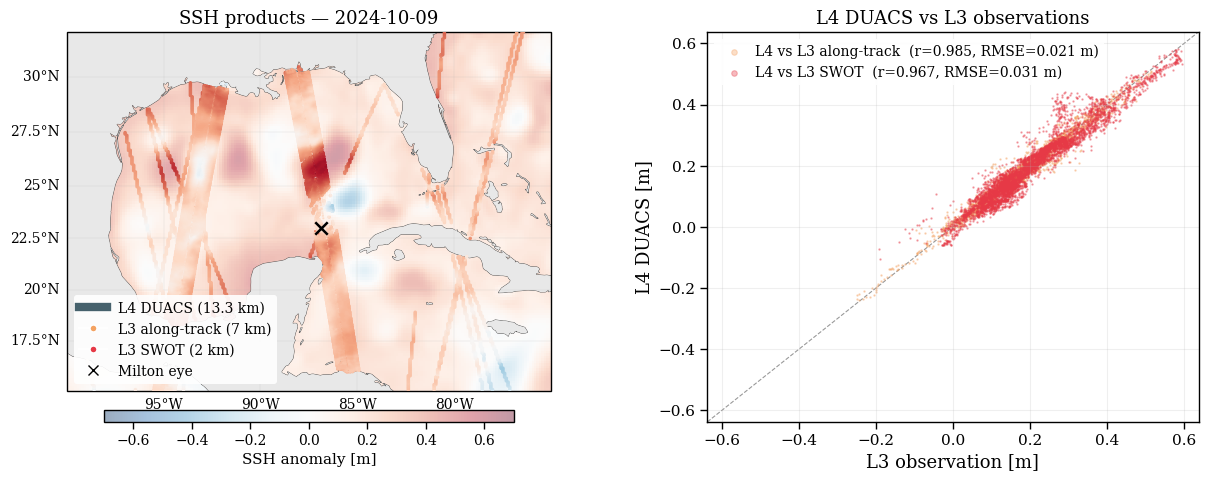

In [4]:
dataset_hf = load_hf_dataset(HF_URL)

print("Loading products...")
data = {}
for key, (_fname, _var, label, _color) in PRODUCTS.items():
    da = load_product(dataset_hf, DATE, key, cache_dir=CACHE_DIR)
    if da is not None:
        data[key] = da
        print(f"  {label:30s}: loaded")
    else:
        print(f"  {label:30s}: not found")

if not data:
    raise RuntimeError("No products found for the selected date.")

print("\nGenerating figure...")
make_figure(data, DATE, output_path=OUTPUT)